---
# Scipy (https://www.scipy.org/)

Slides adapted from https://github.com/iastro-pt/IAPythonCourses/


In [1]:
import numpy as np 
import matplotlib.pyplot as mplt
import scipy as sp
print(sp.__doc__[:180])


SciPy: A scientific computing package for Python

Documentation is available in the docstrings and
online at https://docs.scipy.or


## - Interpolation Tools (scipy.interpolate)

### &rarr;  1-D interpolation (interp1d)


{'linear': <scipy.interpolate._interpolate.interp1d object at 0x7fe04496b6d0>, 'quadratic': <scipy.interpolate._interpolate.interp1d object at 0x7fe044ccf0e0>, 'cubic': <scipy.interpolate._interpolate.interp1d object at 0x7fe046f2b950>}


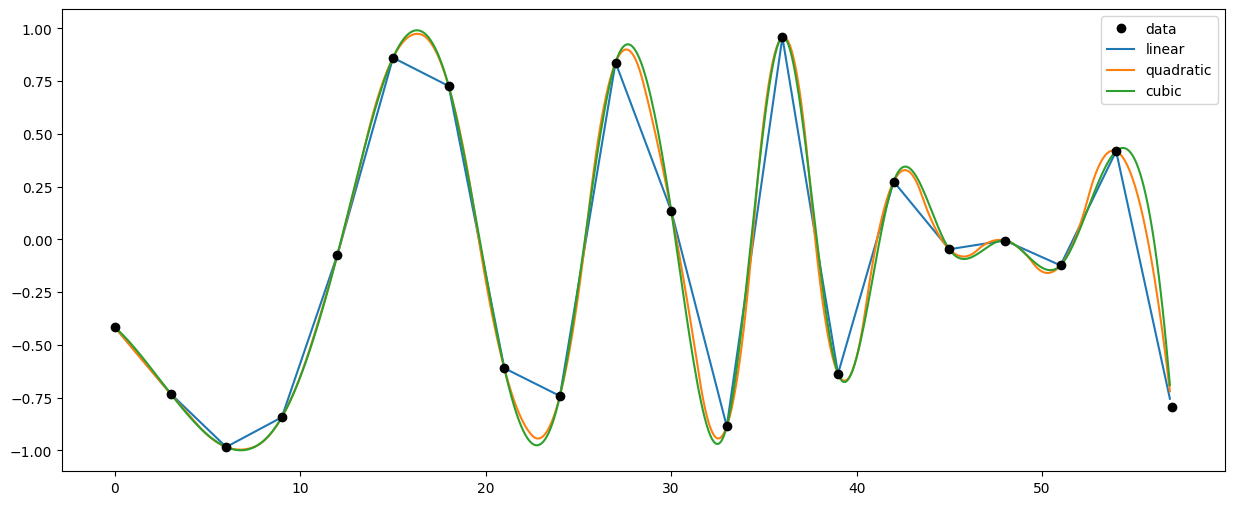

In [13]:
from scipy.interpolate import interp1d

# create data
x = np.arange(0, 60, 3)
y = np.cos ( x / 10 + 2 + (x / 10 )**2 ) 

# define plot
mplt.figure(figsize = (15,6))
mplt.plot(x,y,color = 'k', marker = 'o',label = 'data', zorder=1000, ls="")

# create interpolation functions
interps= ['linear','quadratic','cubic']
funcs = {interp:interp1d(x, y, 
                         kind=interp,
                         fill_value=np.nanmedian(y)
                         ) for interp in interps}

print(funcs)
# define new x array
x_new = np.arange(0, 57, 0.1)

for interp, interpolator in funcs.items():
   mplt.plot(x_new, interpolator(x_new),label = interp)

mplt.legend()


### &rarr;  2-D interpolation (griddata)

`griddata(points, values, xi[, method, …])` - Interpolate unstructured 2-D data.

In [7]:
# Generate 2-D data grid
grid_x, grid_y = np.mgrid[0:1:100j, 0:1:200j]

# model function
def func(x, y):
    return x*(1-x)*np.cos(4*np.pi*x) * np.sin(4*np.pi*y**2)**2

# data points
points = np.random.rand(1000, 2)
values = func(points[:,0], points[:,1])


In [9]:
from scipy.interpolate import griddata
# Fit data with different methods
grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')

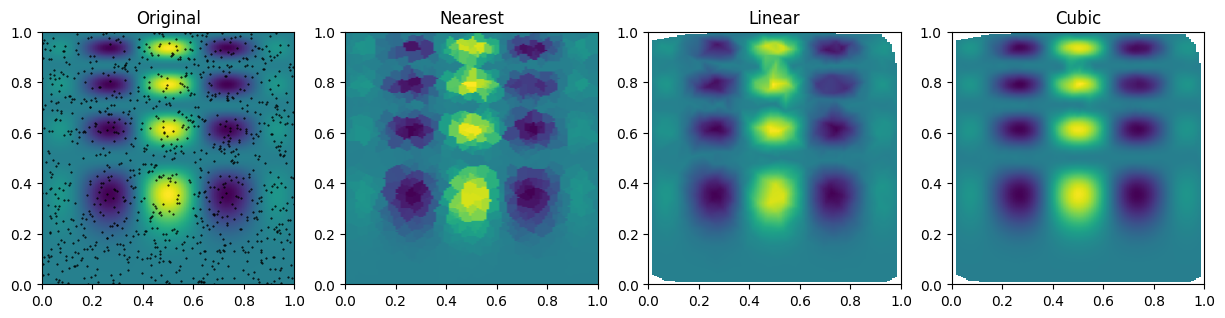

In [10]:
# Plots
import matplotlib.pyplot as plt
mplt.figure(figsize=(15,6))
mplt.subplot(141)
mplt.imshow(func(grid_x, grid_y).T, extent=(0,1,0,1), origin='lower')
mplt.plot(points[:,0], points[:,1], 'k.', ms=1)
mplt.title('Original')
mplt.subplot(142)
mplt.imshow(grid_z0.T, extent=(0,1,0,1), origin='lower')
mplt.title('Nearest')
mplt.subplot(143)
mplt.imshow(grid_z1.T, extent=(0,1,0,1), origin='lower')
mplt.title('Linear')
mplt.subplot(144)
mplt.imshow(grid_z2.T, extent=(0,1,0,1), origin='lower')
mplt.title('Cubic')

mplt.show()

### &rarr;  Spline interpolation
...

https://docs.scipy.org/doc/scipy-1.6.2/reference/tutorial/interpolate.html


## - Optimization tools (scipy.optimize)



In [15]:
# Generating some data to fit 

x = np.random.uniform(-5, 5., 100)
y_params = [2.,3.,-5.]
y = y_params[0] + y_params[1] * x + y_params[2] * x**2 + np.random.normal(0, 10., 100) 
e = np.random.normal(1., 5., 100) # error

# model that defines the data
def poly2(x, a, b,c):
    return a  + b * x + c * x**2 

### &rarr; Curve fitting 


`scipy.optimize.curve_fit(f, xdata, ydata[, p0, sigma, …])` - Use non-linear least squares to fit a function, f, to data.

In [16]:
from scipy.optimize import curve_fit


# fit results
popt, pcov = curve_fit(poly2,
                       x,
                       y,
                       sigma=e
                       )
print("a =", popt[0])
print("b =", popt[1])
print("c =", popt[2])


a = 1.8405531448817154
b = 2.408079567474774
c = -5.4586883760844715


In [25]:
from scipy.optimize import minimize

def poly2(x, a, b,c):
    return a  + b * x + c * x**2 

# fit results
res = minimize(fun=lambda values: np.sum(poly2(x, *values) - y)**2,
                       x0=[1.8, 2.4, -5.45],
                       
                       )
print(res)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 2.325440345952614e-12
        x: [ 1.847e+00  2.397e+00 -5.022e+00]
      nit: 1
      jac: [ 4.540e-04 -2.003e-05  1.521e-02]
 hess_inv: [[ 9.882e-01  8.048e-04 -1.082e-01]
            [ 8.048e-04  9.999e-01  7.349e-03]
            [-1.082e-01  7.349e-03  1.190e-02]]
     nfev: 104
     njev: 23


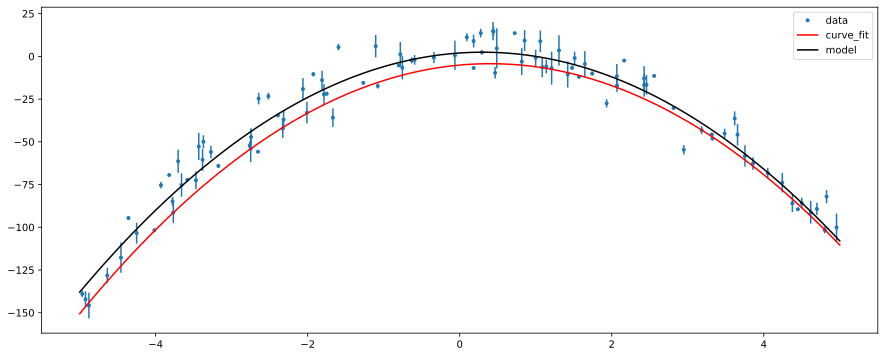

In [34]:
# plots
mplt.figure(figsize = (15,6))
mplt.plot(x, y, '.',label='data')
mplt.errorbar(x, y, yerr=e, fmt="none")
xfine = np.linspace(-5, 5., 100)
mplt.plot(xfine, poly2(xfine, popt[0], popt[1], popt[2]), 'r-',label='curve_fit')
mplt.plot(xfine, poly2(xfine, y_params[0], y_params[1], y_params[2]), 'k-',label='model')
mplt.legend()

### &rarr; nonlinear least-squares fitting 

`scipy.optimize.least_squares(fun, x0[, jac, bounds, …])` - Solve a nonlinear least-squares problem with bounds on the variables.

In [135]:
from scipy.optimize import least_squares
# minimizing function
def fun(params):
    return poly2(x,params[0],params[1],params[2]) - y

# initial parameters
params_ini = [10,-2,3]

# fit results
params_fit = least_squares(fun, params_ini)
print("a =", params_fit['x'][0])
print("b =", params_fit['x'][1])
print("c =", params_fit['x'][2])



a = -0.22494143814307935
b = 2.8486766255807696
c = -4.815557137979419


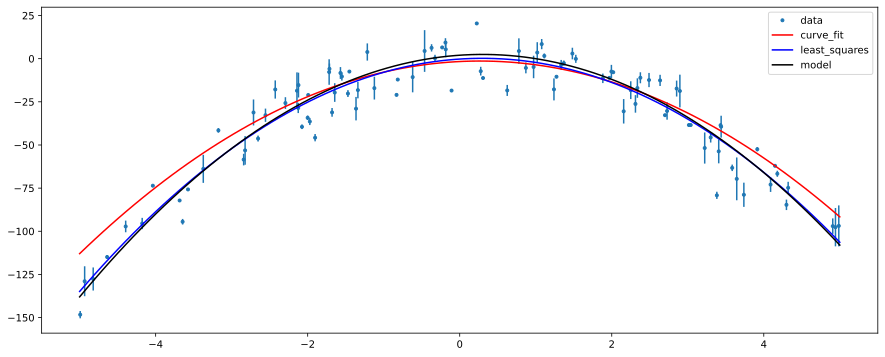

In [136]:
# plots
mplt.figure(figsize = (15,6))
mplt.plot(x, y, '.',label='data')
mplt.errorbar(x, y, yerr=e, fmt="none")
xfine = np.linspace(-5, 5., 100)
mplt.plot(xfine, poly2(xfine, popt[0], popt[1], popt[2]), 'r-',label='curve_fit')
mplt.plot(xfine, poly2(xfine, params_fit['x'][0], params_fit['x'][1], params_fit['x'][2]), 'b-',label = 'least_squares')
mplt.plot(xfine, poly2(xfine, y_params[0], y_params[1], y_params[2]), 'k-',label='model')
mplt.legend()

### ...

https://docs.scipy.org/doc/scipy-1.6.2/reference/tutorial/optimize.html

